# Notebook TOYS — Certification SDP sur Blob

Instance 2D jouet pour tester et visualiser la librairie FastSDPCertification.  
Réseau `blob_nn_4x10` (architecture 2-10-10-10-10-3), dataset Blob 3 classes, ε=0.5 (L∞).

**Plan :**
1. Chargement du problème depuis YAML
2. Exploration du dataset
3. Frontière de décision du réseau
4. Certification SDP sur un sample
5. Visualisation des résultats de certification
6. Certification de plusieurs samples

In [2]:
yaml_file = 'blob_4x10.yaml'  # Config dans FastSDPCertification/config/

## 0. Setup — imports

In [3]:
import sys, os
sys.path.insert(0, "/share/homes/boyerma/FastSDPCertification/src")

import yaml
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.lines import Line2D
from torch.utils.data import DataLoader

from fastsdp_tools import get_project_path
from fastsdp_tools.yaml_config import FullCertificationConfig
from data import load_dataset
from networks import ReLUNN
from certification_problem import Certification_Problem

print("Imports OK")

/users/b/boyerma/share/homes/boyerma/miniconda3/envs/certif/lib/python3.10/site-packages/torch/_jit_internal.py:874: FutureWarning: ignore(True) has been deprecated. TorchScript will now drop the function call on compilation. Use torch.jit.unused now. {}
  warnings.warn(


Imports OK


## 1. Chargement du problème depuis YAML

In [4]:
# Lecture du fichier YAML
with open(get_project_path(f"config/{yaml_file}"), "r") as f:
    config = yaml.safe_load(f)

epsilon = config["input_ball"]["epsilon"]
norm    = config["input_ball"]["norm"]
K       = config["network"]["K"]
n       = config["network"]["n"]

print(f"Réseau  : {config['network']['name']}")
print(f"Archi   : {' -> '.join(map(str, n))}")
print(f"Dataset : {config['data']['name']} ({config['data']['num_samples']} samples, {config['data']['num_classes']} classes)")
print(f"Boule   : ε={epsilon}, norme={norm}")

Réseau  : blob_nn_4x10
Archi   : 2 -> 10 -> 10 -> 10 -> 10 -> 3
Dataset : blob (1000 samples, 3 classes)
Boule   : ε=0.5, norme=Linf


In [5]:
# Chargement dataset, réseau, config validée
dataset          = load_dataset(get_project_path(f"config/{yaml_file}"))
network          = ReLUNN.from_pth(get_project_path(config["network"]["path"]), bb_beta_crown=False)
validated_config = FullCertificationConfig(**config)

solver_config = validated_config.models[0]  # Premier modèle de la config (MdSDP)

print(f"Dataset : {len(dataset)} samples")
print(f"Modèle  : {solver_config.certification_model_name}")
print(f"Coupes  : {solver_config.cuts}")

config :  {'data': {'name': 'blob', 'path': 'data/datasets/blob_dataset.pth', 'num_classes': 3, 'num_samples': 1000}, 'input_ball': {'norm': 'Linf', 'epsilon': 0.5}, 'divide_run': 5, 'network': {'name': 'blob_nn_4x10', 'path': 'data/models/blob_adv_blob_nn_4x10.pt', 'K': 5, 'n': [2, 10, 10, 10, 10, 3]}, 'models': [{'certification_model_name': 'MdSDP', 'write_model': True, 'cuts': ['RLT', 'triangularization', 'McCormick_beta_z', 'beta_logits_comparaison'], 'RLT_props': [1.0], 'all_combinations_cuts': False, 'MATRIX_BY_LAYERS': True, 'LAST_LAYER': False, 'INPUT_IN_VARIABLES': True, 'use_fusion': True, 'use_callback': False, 'use_active_neurons': False, 'use_inactive_neurons': False, 'keep_penultimate_actives': True, 'bounds_file': 'data/bounds/blob_4x10-0.5_linf.csv', 'bounds_method': 'from_file'}]}
Dataset : 1000 samples
Modèle  : MdSDP
Coupes  : ['RLT', 'triangularization', 'McCormick_beta_z', 'beta_logits_comparaison']


## 2. Exploration du dataset

Le dataset Blob est en 2D — idéal pour visualiser les boules ε et la frontière de décision.

In [6]:
# Extraction de tous les points
all_x = torch.stack([x for x, y in dataset])  # (N, 2)
all_y = torch.stack([y for x, y in dataset])   # (N,)

print(f"Shape X : {all_x.shape}")
print(f"Classes : {all_y.unique().tolist()}")
for c in all_y.unique():
    print(f"  Classe {c.item()} : {(all_y == c).sum().item()} samples")

# Statistiques par classe
for c in all_y.unique():
    mask = all_y == c
    print(f"  Classe {c.item()} — mean=({all_x[mask, 0].mean():.2f}, {all_x[mask, 1].mean():.2f})")

Shape X : torch.Size([1000, 2])
Classes : [0, 1, 2]
  Classe 0 : 334 samples
  Classe 1 : 333 samples
  Classe 2 : 333 samples
  Classe 0 — mean=(2.10, 4.15)
  Classe 1 — mean=(4.26, 2.62)
  Classe 2 — mean=(0.81, 0.67)


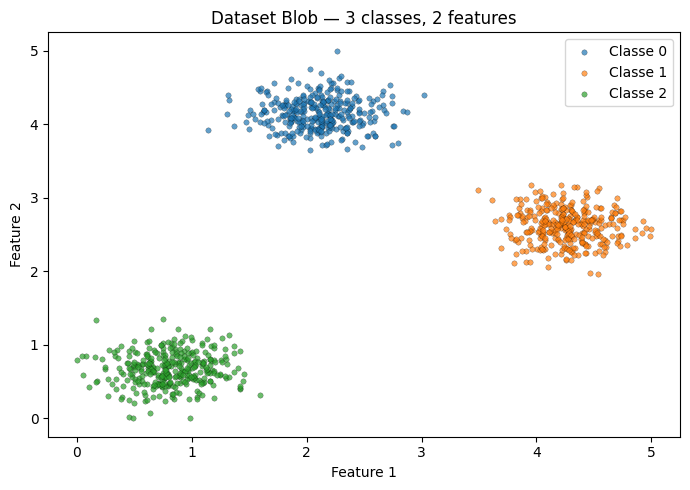

In [7]:
# Scatter plot du dataset
colors = ['tab:blue', 'tab:orange', 'tab:green']

fig, ax = plt.subplots(figsize=(7, 5))
for c in range(n[-1]):
    mask = all_y == c
    ax.scatter(all_x[mask, 0], all_x[mask, 1], c=colors[c], s=15,
               edgecolors='k', linewidths=0.2, label=f"Classe {c}", alpha=0.7)

ax.set_title("Dataset Blob — 3 classes, 2 features")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Frontière de décision du réseau

On évalue le réseau sur une grille 2D pour tracer la frontière de décision.

In [8]:
# Grille de prédiction
x_min = float(all_x[:, 0].min()) - 0.3
x_max = float(all_x[:, 0].max()) + 0.3
y_min = float(all_x[:, 1].min()) - 0.3
y_max = float(all_x[:, 1].max()) + 0.3

GRID_RES = 300
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, GRID_RES),
    np.linspace(y_min, y_max, GRID_RES)
)
grid_pts = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])

network.eval()
with torch.no_grad():
    grid_preds = network(grid_pts).argmax(dim=1).numpy()
grid_preds = grid_preds.reshape(xx.shape)

# Taux d'erreur du réseau sur le dataset
network.eval()
with torch.no_grad():
    logits = network(all_x)
    predicted = logits.argmax(dim=1)
accuracy = (predicted == all_y).float().mean().item()
print(f"Accuracy réseau sur le dataset : {accuracy:.1%}")

Accuracy réseau sur le dataset : 99.2%


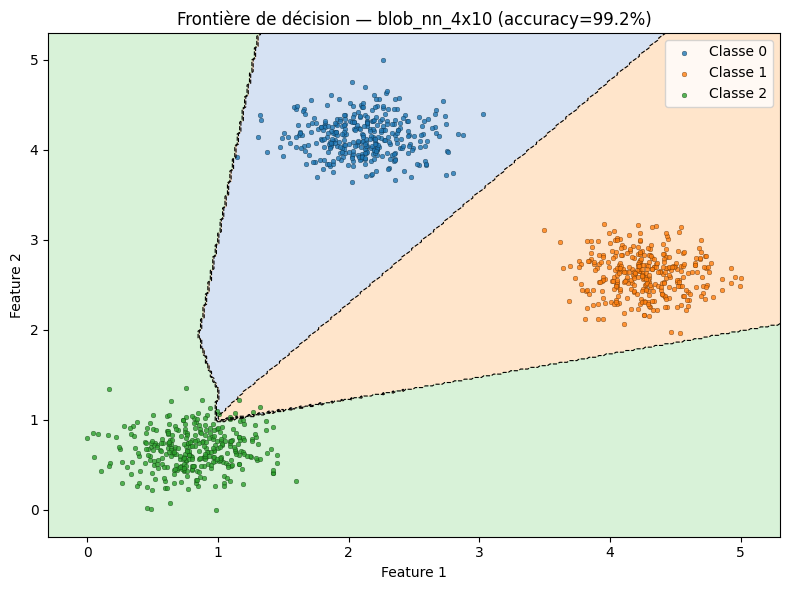

In [8]:
from matplotlib.colors import ListedColormap

cmap_bg   = ListedColormap(['#aec6e8', '#ffcc99', '#b3e6b3'])  # fond
cmap_pts  = ListedColormap(colors)                              # points

fig, ax = plt.subplots(figsize=(8, 6))
ax.contourf(xx, yy, grid_preds, levels=[-0.5, 0.5, 1.5, 2.5], cmap=cmap_bg, alpha=0.5)
ax.contour(xx, yy, grid_preds,  levels=[0.5, 1.5], colors='black', linewidths=0.8, linestyles='--')

for c in range(n[-1]):
    mask = all_y == c
    ax.scatter(all_x[mask, 0], all_x[mask, 1], c=colors[c], s=12,
               edgecolors='k', linewidths=0.2, label=f"Classe {c}", alpha=0.8)

ax.set_title(f"Frontière de décision — {config['network']['name']} (accuracy={accuracy:.1%})")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 4. Certification SDP sur un sample

On instancie `Certification_Problem` et on résout le SDP sur le premier sample correctement classifié.

Le modèle utilisé est **MdSDP** (SDPU — untargeted) avec les coupes RLT, triangularization, McCormick et beta_logits. Les bornes sont pré-calculées (`bounds_method='from_file'`).

In [9]:
# Choix d'un sample à certifier (premier sample bien classifié)
SAMPLE_IDX = 0

x_sample, y_sample = dataset[SAMPLE_IDX]
x_sample_v = x_sample.view(-1)

network.eval()
with torch.no_grad():
    y_pred = network(x_sample_v.unsqueeze(0)).argmax().item()

print(f"Sample  idx   : {SAMPLE_IDX}")
print(f"Vraie classe  : {y_sample.item()}")
print(f"Classe prédite: {y_pred}")
print(f"Coordonnées   : ({x_sample_v[0]:.3f}, {x_sample_v[1]:.3f})")
print(f"Boule L∞      : carré de côté {2*epsilon:.2f} centré sur le point")

Sample  idx   : 0
Vraie classe  : 2
Classe prédite: 2
Coordonnées   : (0.890, 0.591)
Boule L∞      : carré de côté 1.00 centré sur le point


In [11]:
# Lancement de la certification sur 1 sample
RUN_NAME = "toys_notebook_single"

certif_problem = Certification_Problem.load_from_yaml(yaml_file)
certif_problem.run(solver_config, title_run=RUN_NAME, start=SAMPLE_IDX, end=SAMPLE_IDX + 1)

print("\nCertification terminée.")

Loading certification problem from blob_4x10.yaml ...
Loading dataset ...
config :  {'data': {'name': 'blob', 'path': 'data/datasets/blob_dataset.pth', 'num_classes': 3, 'num_samples': 1000}, 'input_ball': {'norm': 'Linf', 'epsilon': 0.5}, 'divide_run': 5, 'network': {'name': 'blob_nn_4x10', 'path': 'data/models/blob_adv_blob_nn_4x10.pt', 'K': 5, 'n': [2, 10, 10, 10, 10, 3]}, 'models': [{'certification_model_name': 'MdSDP', 'write_model': True, 'cuts': ['RLT', 'triangularization', 'McCormick_beta_z', 'beta_logits_comparaison'], 'RLT_props': [1.0], 'all_combinations_cuts': False, 'MATRIX_BY_LAYERS': True, 'LAST_LAYER': False, 'INPUT_IN_VARIABLES': True, 'use_fusion': True, 'use_callback': False, 'use_active_neurons': False, 'use_inactive_neurons': False, 'keep_penultimate_actives': True, 'bounds_file': 'data/bounds/blob_4x10-0.5_linf.csv', 'bounds_method': 'from_file'}]}
Dataset loaded successfully.
Loading epsilon ...
CONFIG  inf CERTIFICATION PROBLEM:      {'data': {'name': 'blob', 'p

In [15]:
# Lecture du fichier de résultats
results_path = get_project_path(f"results/benchmark/blob_nn_4x10-{epsilon}/{RUN_NAME}/results.csv")
results = pd.read_csv(results_path)

cols_display = ["data_index", "label", "optimal_value", "status", "time", "Nb_constraints", "Nb_stable_actives", "Nb_stable_inactives"]
display_cols = [c for c in cols_display if c in results.columns]
results[display_cols]

,data_index,label,optimal_value,status,time,Nb_constraints,Nb_stable_actives,Nb_stable_inactives
0,0,2,-9.339217,SolutionStatus.Optimal,0.129599,692,4,11


In [16]:
# Interprétation du résultat
row = results.iloc[0]
opt_val = row.get("optimal_value", row.get("dual_obj_value", None))

if opt_val is not None and float(opt_val) > 0:
    print(f"✔ Sample {int(row['data_index'])} CERTIFIÉ ROBUSTE (val={float(opt_val):.4f} > 0)")
    print(f"  Pour toute perturbation dans la boule L∞ de rayon ε={epsilon}, le réseau prédit toujours la classe {int(row['label'])}.")
else:
    print(f"✗ Sample {int(row['data_index'])} NON CERTIFIÉ (val={float(opt_val):.4f} ≤ 0)")
    print(f"  Le SDP n'a pas pu certifier la robustesse — cela ne signifie pas que le réseau est vulnérable (relaxation SDP).")

✗ Sample 0 NON CERTIFIÉ (val=-9.3392 ≤ 0)
  Le SDP n'a pas pu certifier la robustesse — cela ne signifie pas que le réseau est vulnérable (relaxation SDP).


## 5. Visualisation du résultat de certification

On trace le point certifié (ou non) avec sa boule L∞ (carré) sur la frontière de décision.

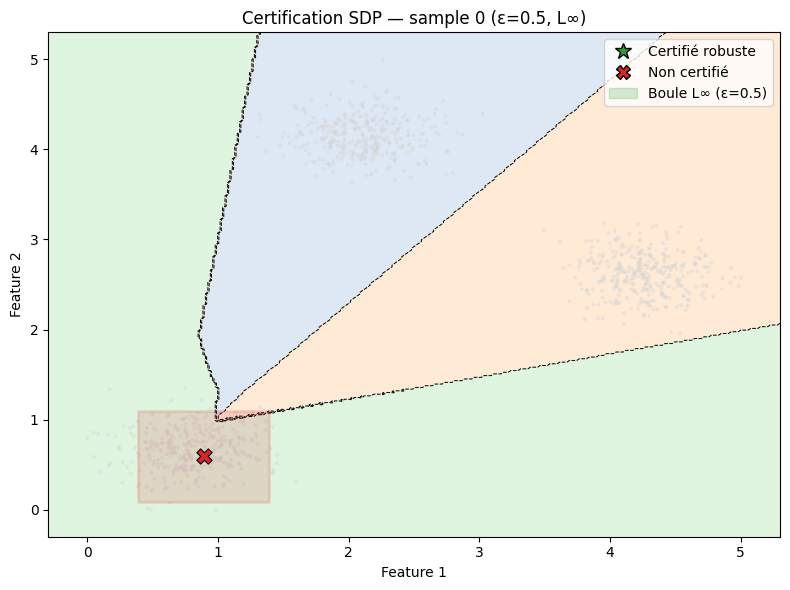

In [17]:
def plot_certification_result(ax, results_df, dataset, all_x, xx, yy, grid_preds,
                              epsilon, title="Résultats de certification"):
    """Trace la frontière de décision + résultats de certification (boules ε)."""
    cmap_bg = ListedColormap(['#aec6e8', '#ffcc99', '#b3e6b3'])
    ax.contourf(xx, yy, grid_preds, levels=[-0.5, 0.5, 1.5, 2.5], cmap=cmap_bg, alpha=0.4)
    ax.contour(xx, yy, grid_preds, levels=[0.5, 1.5], colors='black', linewidths=0.7, linestyles='--')

    # Tous les points en gris clair
    ax.scatter(all_x[:, 0], all_x[:, 1], c='lightgray', s=8, edgecolors='none', alpha=0.4, zorder=1)

    for _, row in results_df.iterrows():
        idx = int(row["data_index"])
        x_pt, _ = dataset[idx]
        x_pt = x_pt.view(-1)

        opt_col = "optimal_value" if "optimal_value" in row else "dual_obj_value"
        certified = float(row[opt_col]) > 0
        color  = "#2ca02c" if certified else "#d62728"  # vert / rouge
        marker = "*" if certified else "X"

        # Boule L∞ = carré de côté 2ε
        rect = patches.Rectangle(
            (float(x_pt[0]) - epsilon, float(x_pt[1]) - epsilon),
            2 * epsilon, 2 * epsilon,
            linewidth=2, edgecolor=color, facecolor=color, alpha=0.15, zorder=2
        )
        ax.add_patch(rect)
        ax.scatter(float(x_pt[0]), float(x_pt[1]), c=color, s=120, marker=marker,
                   edgecolors='black', linewidths=0.8, zorder=5)

    legend_elements = [
        Line2D([0], [0], marker='*', color='w', markerfacecolor='#2ca02c', markersize=12,
               markeredgecolor='black', label='Certifié robuste'),
        Line2D([0], [0], marker='X', color='w', markerfacecolor='#d62728', markersize=10,
               markeredgecolor='black', label='Non certifié'),
        patches.Patch(facecolor='#2ca02c', alpha=0.2, edgecolor='#2ca02c', label=f'Boule L∞ (ε={epsilon})'),
    ]
    ax.legend(handles=legend_elements, loc='upper right')
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")


fig, ax = plt.subplots(figsize=(8, 6))
plot_certification_result(
    ax, results, dataset, all_x, xx, yy, grid_preds, epsilon,
    title=f"Certification SDP — sample {SAMPLE_IDX} (ε={epsilon}, L∞)"
)
plt.tight_layout()
plt.show()

## 6. Certification de plusieurs samples

On lance la certification sur un plus grand nombre de samples pour avoir une vue d'ensemble.

> **Note** : chaque résolution SDP prend quelques secondes. Pour `N_SAMPLES=10`, compter ~1-2 min.

In [27]:
N_SAMPLES   = 10   # Nombre de samples à certifier
START_IDX   = 0
RUN_NAME_MULTI = "toys_notebook_multi"

certif_problem_multi = Certification_Problem.load_from_yaml(yaml_file)
certif_problem_multi.run(
    solver_config,
    title_run=RUN_NAME_MULTI,
    start=START_IDX,
    end=START_IDX + N_SAMPLES
)
print("Certification multi-samples terminée.")

Loading certification problem from blob_4x10.yaml ...
Loading dataset ...
config :  {'data': {'name': 'blob', 'path': 'data/datasets/blob_dataset.pth', 'num_classes': 3, 'num_samples': 1000}, 'input_ball': {'norm': 'Linf', 'epsilon': 0.5}, 'divide_run': 5, 'network': {'name': 'blob_nn_4x10', 'path': 'data/models/blob_adv_blob_nn_4x10.pt', 'K': 5, 'n': [2, 10, 10, 10, 10, 3]}, 'models': [{'certification_model_name': 'MdSDP', 'write_model': True, 'cuts': ['RLT', 'triangularization', 'McCormick_beta_z', 'beta_logits_comparaison'], 'RLT_props': [1.0], 'all_combinations_cuts': False, 'MATRIX_BY_LAYERS': True, 'LAST_LAYER': False, 'INPUT_IN_VARIABLES': True, 'use_fusion': True, 'use_callback': False, 'use_active_neurons': False, 'use_inactive_neurons': False, 'keep_penultimate_actives': True, 'bounds_file': 'data/bounds/blob_4x10-0.5_linf.csv', 'bounds_method': 'from_file'}]}
Dataset loaded successfully.
Loading epsilon ...
CONFIG  inf CERTIFICATION PROBLEM:      {'data': {'name': 'blob', 'p

Adding RLT constraint
Indexes pruned for layer 1 : []
Indexes pruned for layer 2 : [3, 4, 5, 6, 7]
Indexes pruned for layer 3 : [3, 4, 5, 6, 8]
Indexes pruned for layer 4 : [0, 1, 2, 8]
CALLBACK : RLT = 119
Adding first term equal zero constraint
Adding rec matrices constraint
Number of constraints for the matrix by layers: 16 for 5 layers, [ 2 10 10 10 10  3] neurons, boundary layers: [1, 2, 3]
CALLBACK : Ending constraints. Total number of constraints :  692
Getting histogram of coefficients...
INFO     18:24:55     [objective_fusion.py:117] Adding objective to the task
CALLBACK : Number of constraints : 692
Writing ptf :  results/benchmark/blob_nn_4x10-0.5/toys_notebook_multi/MdSDP/MdSDP_RLT_triangularization_McCormick_beta_z_beta_logits_comparaison_ind=0_ytarget=None_RLT=1.0_fusion.ptf
STUDY : Pretreatment computing time:  0.9430570602416992
CALLBACK : Getting results ...
Status of the solution:  SolutionStatus.Optimal
CALLBACK : optimal status
Optimal solution found with objective

In [28]:
results_multi_path = get_project_path(f"results/benchmark/blob_nn_4x10-{epsilon}/{RUN_NAME_MULTI}/results.csv")
results_multi = pd.read_csv(results_multi_path)

opt_col = "optimal_value" if "optimal_value" in results_multi.columns else "dual_obj_value"
results_multi["certified"] = results_multi[opt_col].astype(float) > 0

n_certified    = results_multi["certified"].sum()
n_total        = len(results_multi)
avg_time       = results_multi.get("time", pd.Series([float("nan")])).mean()

print(f"Samples certifiés : {n_certified}/{n_total} ({n_certified/n_total:.0%})")
print(f"Temps moyen/sample: {avg_time:.1f}s")
print()

display_cols = [c for c in ["data_index", "label", opt_col, "certified", "status", "time"] if c in results_multi.columns]
results_multi[display_cols].sort_values("data_index")

Samples certifiés : 4/10 (40%)
Temps moyen/sample: 0.1s



,data_index,label,optimal_value,certified,status,time
0,0,2,-9.339217,False,SolutionStatus.Optimal,0.104327
1,1,2,-10.558941,False,SolutionStatus.Optimal,0.091167
2,2,1,2.040245,True,SolutionStatus.Optimal,0.025254
3,3,0,-0.025829,False,SolutionStatus.Optimal,0.075718
4,4,0,-0.659559,False,SolutionStatus.Optimal,0.035697
5,5,2,-10.472198,False,SolutionStatus.Optimal,0.099039
6,6,1,3.049811,True,SolutionStatus.Optimal,0.019590
7,7,1,2.403525,True,SolutionStatus.Optimal,0.026445
8,8,1,3.507226,True,SolutionStatus.Optimal,0.020504
9,9,1,-11.338999,False,SolutionStatus.Optimal,0.082686


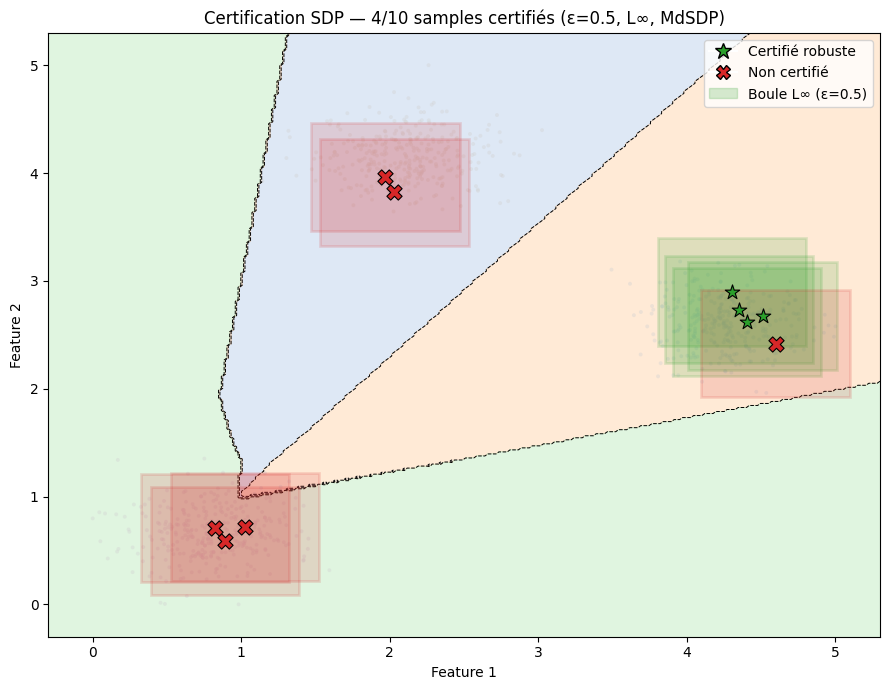

In [29]:
fig, ax = plt.subplots(figsize=(9, 7))
plot_certification_result(
    ax, results_multi, dataset, all_x, xx, yy, grid_preds, epsilon,
    title=f"Certification SDP — {n_certified}/{n_total} samples certifiés (ε={epsilon}, L∞, MdSDP)"
)
plt.tight_layout()
plt.show()

## 7. Analyse des bornes et neurones stables

Pour chaque sample, on peut inspecter la stabilité des neurones (actifs / inactifs) et la valeur optimale.

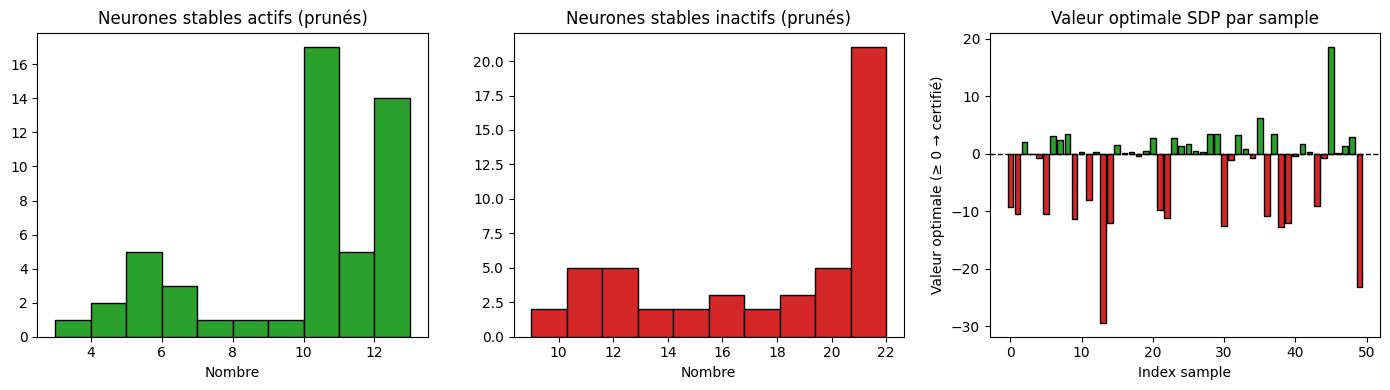

In [26]:
if "Nb_stable_actives" in results_multi.columns:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    # Distribution des neurones stables actifs
    axes[0].hist(results_multi["Nb_stable_actives"].dropna(), bins=10, color='tab:green', edgecolor='black')
    axes[0].set_title("Neurones stables actifs (prunés)")
    axes[0].set_xlabel("Nombre")

    # Distribution des neurones stables inactifs
    axes[1].hist(results_multi["Nb_stable_inactives"].dropna(), bins=10, color='tab:red', edgecolor='black')
    axes[1].set_title("Neurones stables inactifs (prunés)")
    axes[1].set_xlabel("Nombre")

    # Valeur optimale par sample
    opt_vals = results_multi[opt_col].astype(float)
    bar_colors = ['#2ca02c' if v > 0 else '#d62728' for v in opt_vals]
    axes[2].bar(results_multi["data_index"].astype(int), opt_vals, color=bar_colors, edgecolor='black')
    axes[2].axhline(0, color='black', linewidth=1, linestyle='--')
    axes[2].set_title("Valeur optimale SDP par sample")
    axes[2].set_xlabel("Index sample")
    axes[2].set_ylabel("Valeur optimale (≥ 0 → certifié)")

    plt.tight_layout()
    plt.show()
else:
    print("Colonnes Nb_stable_actives/inactives absentes du CSV.")
    # Afficher quand même la valeur optimale
    opt_vals = results_multi[opt_col].astype(float)
    bar_colors = ['#2ca02c' if v > 0 else '#d62728' for v in opt_vals]
    plt.figure(figsize=(8, 4))
    plt.bar(results_multi["data_index"].astype(int), opt_vals, color=bar_colors, edgecolor='black')
    plt.axhline(0, color='black', linewidth=1, linestyle='--')
    plt.title("Valeur optimale SDP par sample (vert=certifié, rouge=non certifié)")
    plt.xlabel("Index sample")
    plt.ylabel("Valeur optimale")
    plt.tight_layout()
    plt.show()